# P1 – Problem Formulation & Exploratory Data Analysis
## Forecasting Turkey's Hourly Electricity Consumption Using Weather and Temporal Features

---

## 1. Problem Statement

**What real-world problem are we solving?**

Accurate short-term electricity consumption forecasting is essential for grid operators, energy traders, and policymakers. Imbalances between supply and demand lead to financial penalties, blackouts, or wasted generation capacity. This project aims to predict Turkey's hourly electricity consumption (MWh) using weather conditions and temporal/calendar features.

**Why does it matter?**

Turkey's electricity grid serves over 85 million people. Reliable hourly forecasts help:
- **Grid operators** balance generation and load in real time.
- **Energy companies** optimise bidding strategies on the day-ahead market.
- **Policymakers** plan infrastructure investments.

**Prediction target:** `Tüketim Miktarı(MWh)` — Turkey's total hourly electricity consumption.

**Task type:** **Regression** — the target is a continuous variable measured in MWh.

---
## 2. Dataset Description

| Property | Value |
|---|---|
| **Source** | EPİAŞ (EXIST) Transparency Platform for consumption data; Open-Meteo API for weather data; hand-crafted calendar features |
| **Rows** | 8 592 (hourly observations) |
| **Columns** | 24 |
| **Period** | 2025-01-08 00:00 → 2025-12-31 23:00 |

### Feature descriptions

| Feature | Type | Description |
|---|---|---|
| `Tarih` | datetime-str | Date-time stamp |
| `Saat` | str | Hour of day (HH:MM) |
| `Tüketim Miktarı(MWh)` | float | **Target** – hourly electricity consumption |
| `time` | datetime-str | Unified timestamp |
| `TR_Sicaklik` | float | Temperature (°C) |
| `TR_Nem` | float | Relative humidity (%) |
| `TR_Ruzgar` | float | Wind speed (km/h) |
| `TR_Bulut` | float | Cloud cover (%) |
| `TR_Yagis` | float | Precipitation (mm) |
| `hour` | int | Hour of day (0-23) |
| `day_of_week` | int | Day of week (0=Mon, 6=Sun) |
| `month` | int | Month (1-12) |
| `is_weekend` | int | Binary weekend flag |
| `is_holiday` | int | Binary public holiday flag |
| `is_ramadan` | int | Binary Ramadan flag |
| `is_sahur` | int | Binary sahur-hour flag |
| `load_lag_24` | float | Consumption 24 hours ago |
| `load_lag_168` | float | Consumption 168 hours (1 week) ago |
| `hour_sin`, `hour_cos` | float | Cyclical hour encoding |
| `hour_sq` | int | hour² (non-linear hour effect) |
| `temp_sq` | float | Temperature² (U-shape effect) |
| `HDD` | float | Heating Degree Days (base 18 °C) |
| `load_rolling_mean_24h` | float | 24-hour rolling mean of consumption |

**Known limitations:** Weather data is a country-wide average, not a population-weighted regional composite. Holiday/Ramadan flags are manually encoded and may miss unofficial observances.

---
## 3. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})

df = pd.read_csv('egitime_hazir_final_veri.csv', parse_dates=['time'], index_col='time')
print(f"Shape: {df.shape}")
df.head()

Shape: (8592, 23)


,Tarih,Saat,Tüketim Miktarı(MWh),TR_Sicaklik,TR_Nem,TR_Ruzgar,TR_Bulut,TR_Yagis,hour,day_of_week,...,is_ramadan,is_sahur,load_lag_24,load_lag_168,hour_sin,hour_cos,hour_sq,temp_sq,HDD,load_rolling_mean_24h
time,,,,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,2025-01-08 00:00:00,00:00,36782.17,8.5,83.3,12.9,93.0,0.0,0,2,...,0,0,37369.33,32707.51,0.00,1.00,0,72.25,9.5,41381.66
2025-01-08 01:00:00,2025-01-08 01:00:00,01:00,35192.68,8.4,82.7,12.4,100.0,0.0,1,2,...,0,0,35416.09,31196.05,0.26,0.97,1,70.56,9.6,41372.35
2025-01-08 02:00:00,2025-01-08 02:00:00,02:00,33794.14,8.4,82.7,12.6,98.0,0.0,2,2,...,0,0,34025.14,29674.85,0.50,0.87,4,70.56,9.6,41362.72
2025-01-08 03:00:00,2025-01-08 03:00:00,03:00,33130.11,8.3,83.0,12.6,99.3,0.0,3,2,...,0,0,33324.74,28490.58,0.71,0.71,9,68.89,9.7,41354.62
2025-01-08 04:00:00,2025-01-08 04:00:00,04:00,32843.50,8.2,84.7,11.4,72.0,0.0,4,2,...,0,0,33056.53,28012.95,0.87,0.50,16,67.24,9.8,41345.74


In [2]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8592 entries, 2025-01-08 00:00:00 to 2025-12-31 23:00:00
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Tarih                  8592 non-null   str    
 1   Saat                   8592 non-null   str    
 2   Tüketim Miktarı(MWh)   8592 non-null   float64
 3   TR_Sicaklik            8592 non-null   float64
 4   TR_Nem                 8592 non-null   float64
 5   TR_Ruzgar              8592 non-null   float64
 6   TR_Bulut               8592 non-null   float64
 7   TR_Yagis               8592 non-null   float64
 8   hour                   8592 non-null   int64  
 9   day_of_week            8592 non-null   int64  
 10  month                  8592 non-null   int64  
 11  is_weekend             8592 non-null   int64  
 12  is_holiday             8592 non-null   int64  
 13  is_ramadan             8592 non-null   int64  
 14  is_sahur               8592 non

In [3]:
df.describe().round(2)

,Tüketim Miktarı(MWh),TR_Sicaklik,TR_Nem,TR_Ruzgar,TR_Bulut,TR_Yagis,hour,day_of_week,month,is_weekend,...,is_ramadan,is_sahur,load_lag_24,load_lag_168,hour_sin,hour_cos,hour_sq,temp_sq,HDD,load_rolling_mean_24h
count,8592.00,8592.00,8592.00,8592.00,8592.00,8592.00,8592.00,8592.0,8592.00,8592.00,...,8592.00,8592.00,8592.00,8592.00,8592.00,8592.00,8592.00,8592.00,8592.00,8592.00
mean,40273.11,16.31,61.84,8.90,37.73,0.05,11.50,3.0,6.63,0.28,...,0.08,0.01,40273.26,40211.49,0.00,0.00,180.17,341.32,4.58,40274.09
std,6580.42,8.69,19.15,4.05,32.72,0.24,6.92,2.0,3.39,0.45,...,0.27,0.08,6578.72,6580.04,0.71,0.71,164.86,306.75,5.34,4588.19
min,21419.13,-5.10,13.00,1.00,0.00,0.00,0.00,0.0,1.00,0.00,...,0.00,0.00,21419.13,21419.13,-1.00,-1.00,0.00,0.00,0.00,25028.69
25%,34892.89,9.50,47.70,5.80,4.70,0.00,5.75,1.0,4.00,0.00,...,0.00,0.00,34893.66,34854.08,-0.71,-0.71,33.25,90.25,0.00,37668.10
50%,40512.44,15.70,64.00,8.30,33.70,0.00,11.50,3.0,7.00,0.00,...,0.00,0.00,40514.42,40459.49,0.00,0.00,132.50,246.49,2.30,39844.66
75%,44721.89,22.90,77.70,11.50,65.70,0.00,17.25,5.0,10.00,1.00,...,0.00,0.00,44704.73,44578.30,0.71,0.71,297.75,524.41,8.50,42843.56
max,59503.67,38.80,96.30,25.80,100.00,4.40,23.00,6.0,12.00,1.00,...,1.00,1.00,59503.67,59503.67,1.00,1.00,529.00,1505.44,23.10,52019.23


---
## 4. Data Cleaning

In [4]:
# 4.1 Missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
Tarih                    0
Saat                     0
Tüketim Miktarı(MWh)     0
TR_Sicaklik              0
TR_Nem                   0
TR_Ruzgar                0
TR_Bulut                 0
TR_Yagis                 0
hour                     0
day_of_week              0
month                    0
is_weekend               0
is_holiday               0
is_ramadan               0
is_sahur                 0
load_lag_24              0
load_lag_168             0
hour_sin                 0
hour_cos                 0
hour_sq                  0
temp_sq                  0
HDD                      0
load_rolling_mean_24h    0
dtype: int64

Total missing: 0


In [5]:
# 4.2 Duplicate rows
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup}")

Duplicate rows: 0


In [6]:
# 4.3 Data type corrections
# 'Tarih' and 'Saat' are redundant since 'time' (index) already encodes both → drop them.
# 'load_rolling_mean_24h' will be dropped to avoid target leakage in later modelling.
cols_to_drop = ['Tarih', 'Saat', 'load_rolling_mean_24h']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f"Dropped {cols_to_drop} → new shape: {df.shape}")
print(df.dtypes)

Dropped ['Tarih', 'Saat', 'load_rolling_mean_24h'] → new shape: (8592, 20)
Tüketim Miktarı(MWh)    float64
TR_Sicaklik             float64
TR_Nem                  float64
TR_Ruzgar               float64
TR_Bulut                float64
TR_Yagis                float64
hour                      int64
day_of_week               int64
month                     int64
is_weekend                int64
is_holiday                int64
is_ramadan                int64
is_sahur                  int64
load_lag_24             float64
load_lag_168            float64
hour_sin                float64
hour_cos                float64
hour_sq                   int64
temp_sq                 float64
HDD                     float64
dtype: object


In [7]:
# 4.4 Outlier analysis (IQR method on the target)
target = 'Tüketim Miktarı(MWh)'
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df[target] < lower) | (df[target] > upper)]
print(f"Target IQR outliers: {len(outliers)} / {len(df)} ({100*len(outliers)/len(df):.2f}%)")
print(f"Bounds: [{lower:.0f}, {upper:.0f}] MWh")
print("→ Outliers are kept: they correspond to genuine extreme-weather peaks/troughs, not data errors.")

Target IQR outliers: 1 / 8592 (0.01%)
Bounds: [20149, 59465] MWh
→ Outliers are kept: they correspond to genuine extreme-weather peaks/troughs, not data errors.


In [8]:
# 4.5 Inconsistent categories — check binary flags
for col in ['is_weekend', 'is_holiday', 'is_ramadan', 'is_sahur']:
    print(f"{col}: {sorted(df[col].unique())}")
print("All binary columns contain only 0/1 — no inconsistencies.")

is_weekend: [np.int64(0), np.int64(1)]
is_holiday: [np.int64(0), np.int64(1)]
is_ramadan: [np.int64(0), np.int64(1)]
is_sahur: [np.int64(0), np.int64(1)]
All binary columns contain only 0/1 — no inconsistencies.


---
## 5. Univariate Analysis

### 5.1 Target variable: `Tüketim Miktarı(MWh)`

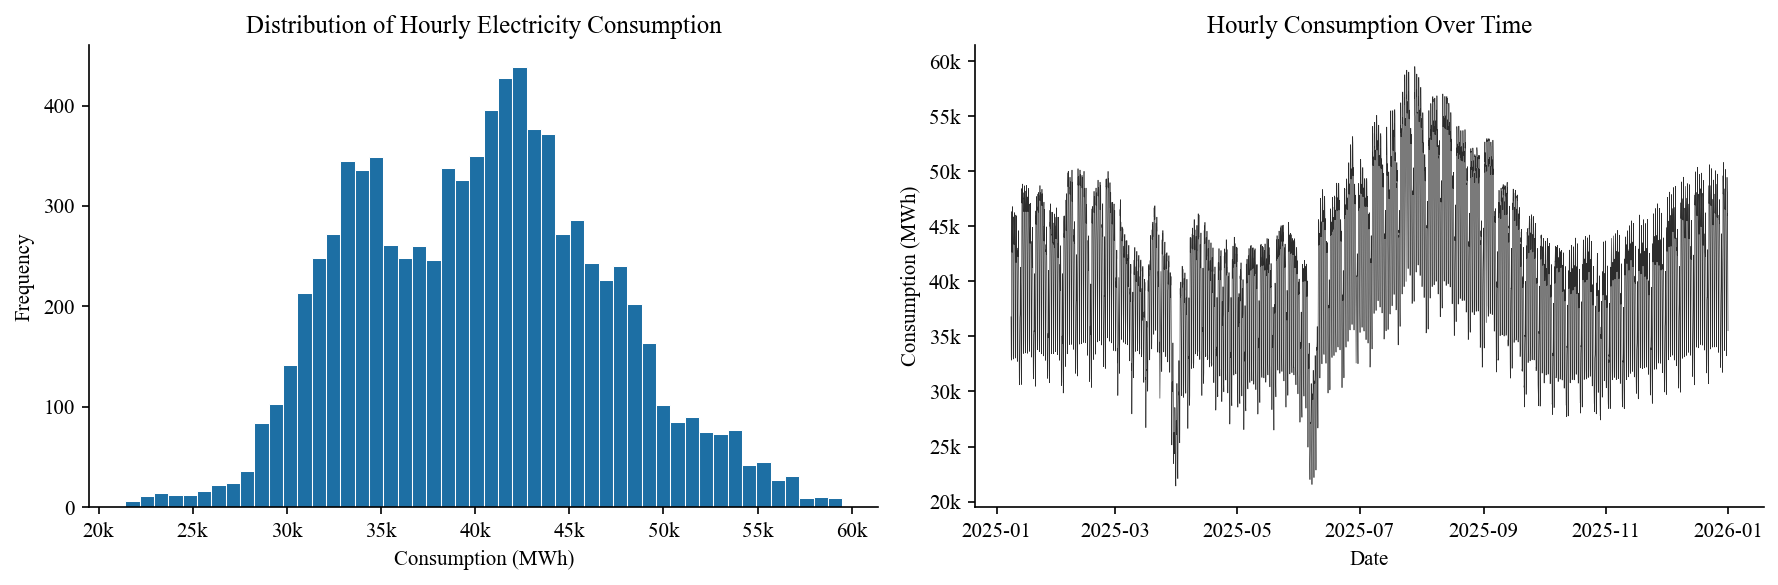

Mean: 40273.1  |  Median: 40512.4  |  Std: 6580.4  |  Skewness: 0.133


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df[target], bins=50, color='#1d6fa4', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Consumption (MWh)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Hourly Electricity Consumption')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Time series
axes[1].plot(df.index, df[target], linewidth=0.3, color='#2c2c2c')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Consumption (MWh)')
axes[1].set_title('Hourly Consumption Over Time')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.show()

print(f"Mean: {df[target].mean():.1f}  |  Median: {df[target].median():.1f}  |  Std: {df[target].std():.1f}  |  Skewness: {df[target].skew():.3f}")

### 5.2 Numerical features

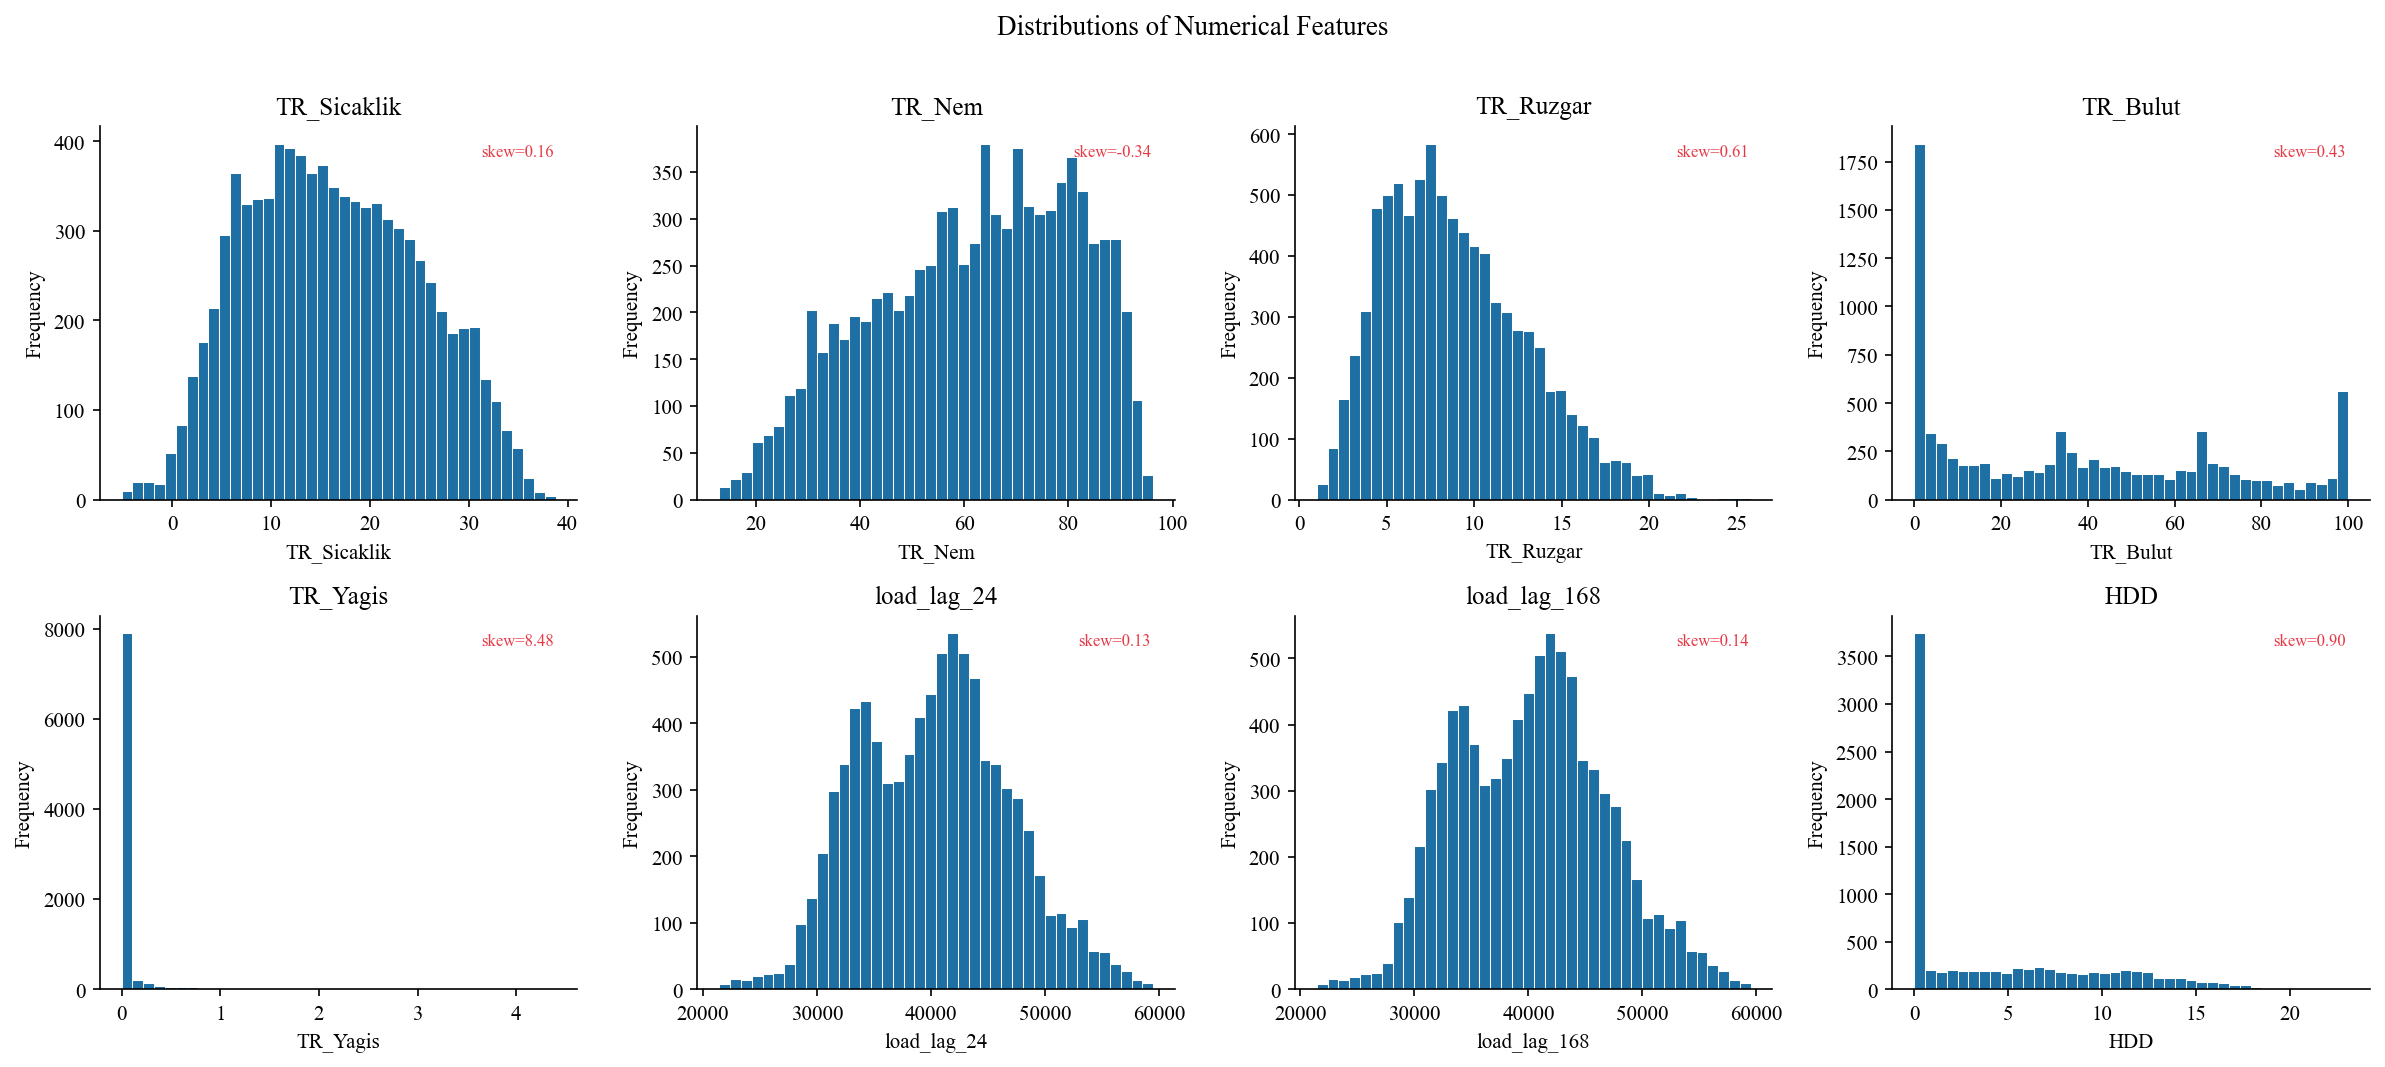

,TR_Sicaklik,TR_Nem,TR_Ruzgar,TR_Bulut,TR_Yagis,load_lag_24,load_lag_168,HDD
mean,16.310,61.840,8.900,37.730,0.050,40273.260,40211.490,4.580
median,15.700,64.000,8.300,33.700,0.000,40514.420,40459.490,2.300
std,8.690,19.150,4.050,32.720,0.240,6578.720,6580.040,5.340
skewness,0.161,-0.336,0.612,0.429,8.484,0.133,0.141,0.903


In [15]:
num_cols = ['TR_Sicaklik', 'TR_Nem', 'TR_Ruzgar', 'TR_Bulut', 'TR_Yagis', 
            'load_lag_24', 'load_lag_168', 'HDD']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='#1d6fa4', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    skew = df[col].skew()
    axes[i].annotate(f'skew={skew:.2f}', xy=(0.95, 0.92), xycoords='axes fraction',
                     ha='right', fontsize=8, color='#e63946')

plt.suptitle('Distributions of Numerical Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
summary = df[num_cols].agg(['mean', 'median', 'std']).round(2)
summary.loc['skewness'] = df[num_cols].skew().round(3)
summary

---
## 6. Bivariate & Multivariate Analysis

### 6.1 Correlation heatmap

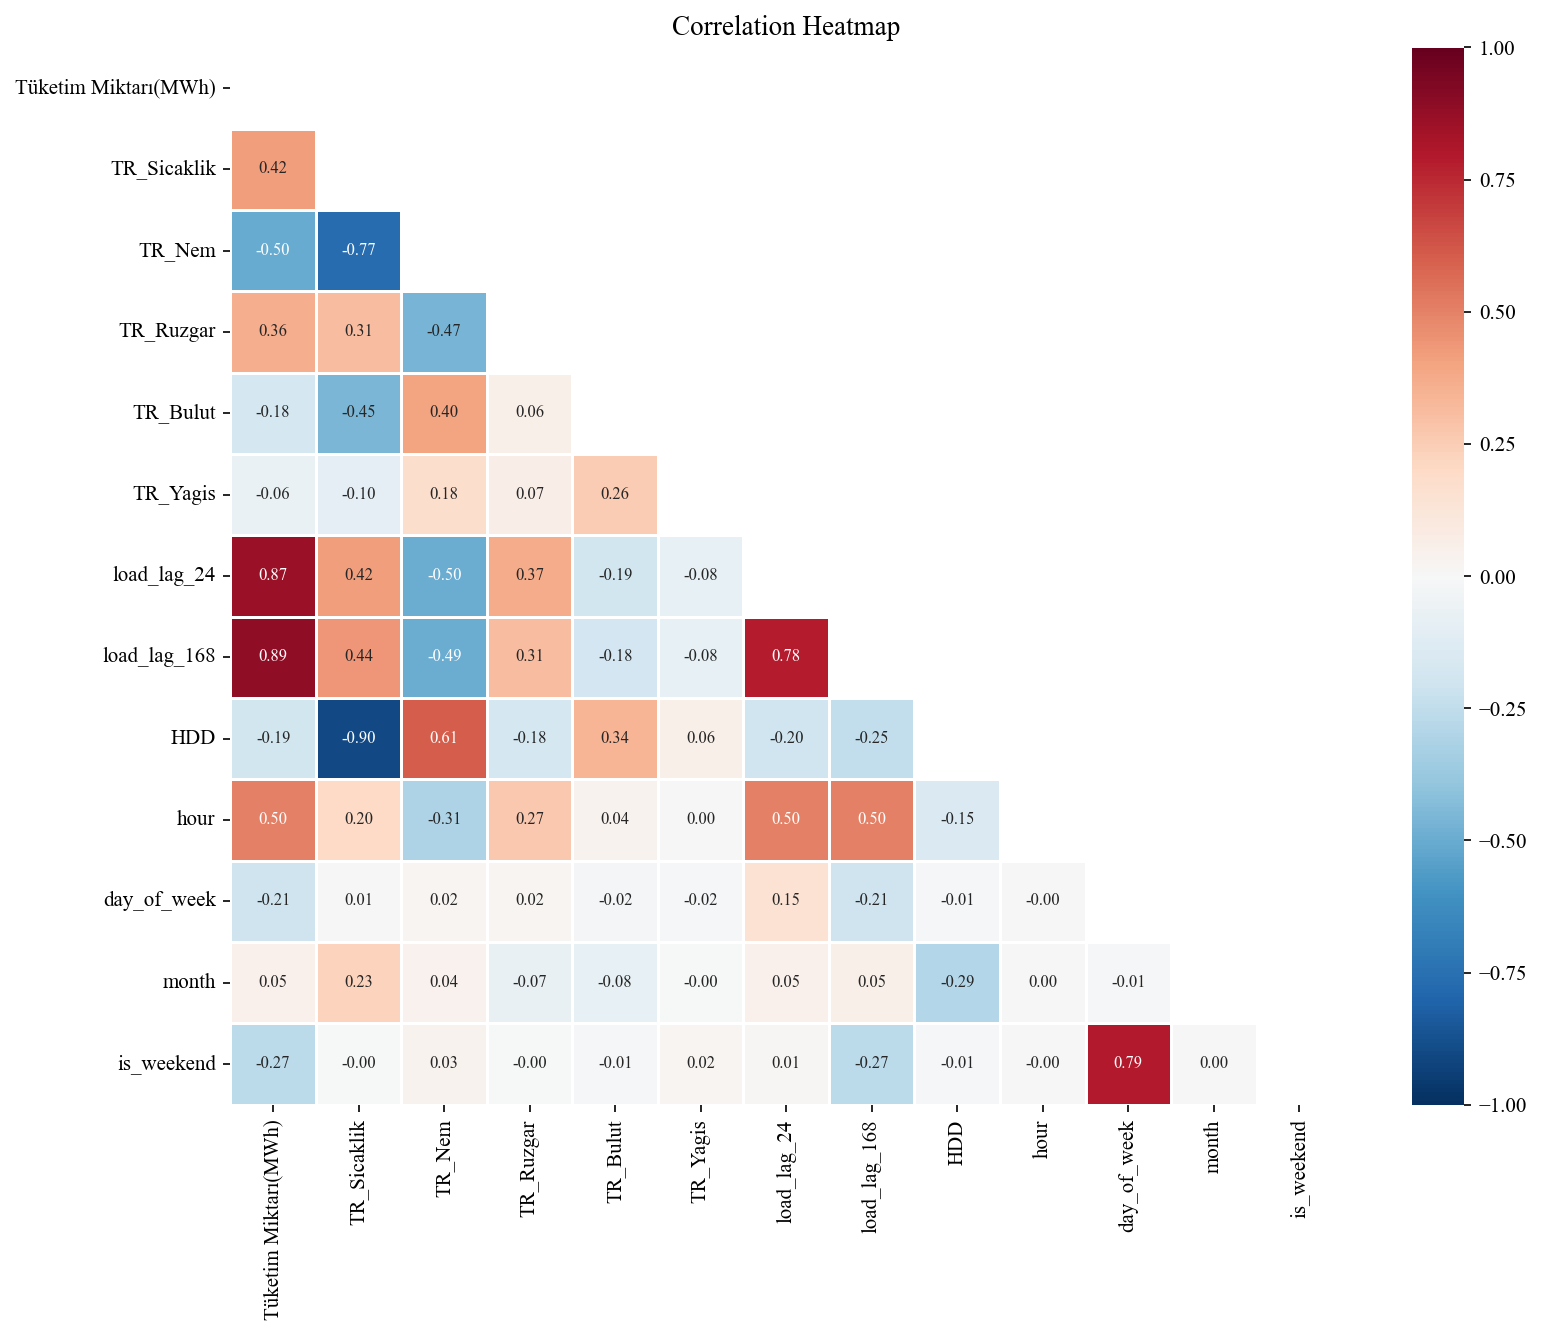

In [12]:
corr_cols = [target] + num_cols + ['hour', 'day_of_week', 'month', 'is_weekend']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

### 6.2 Top features vs target

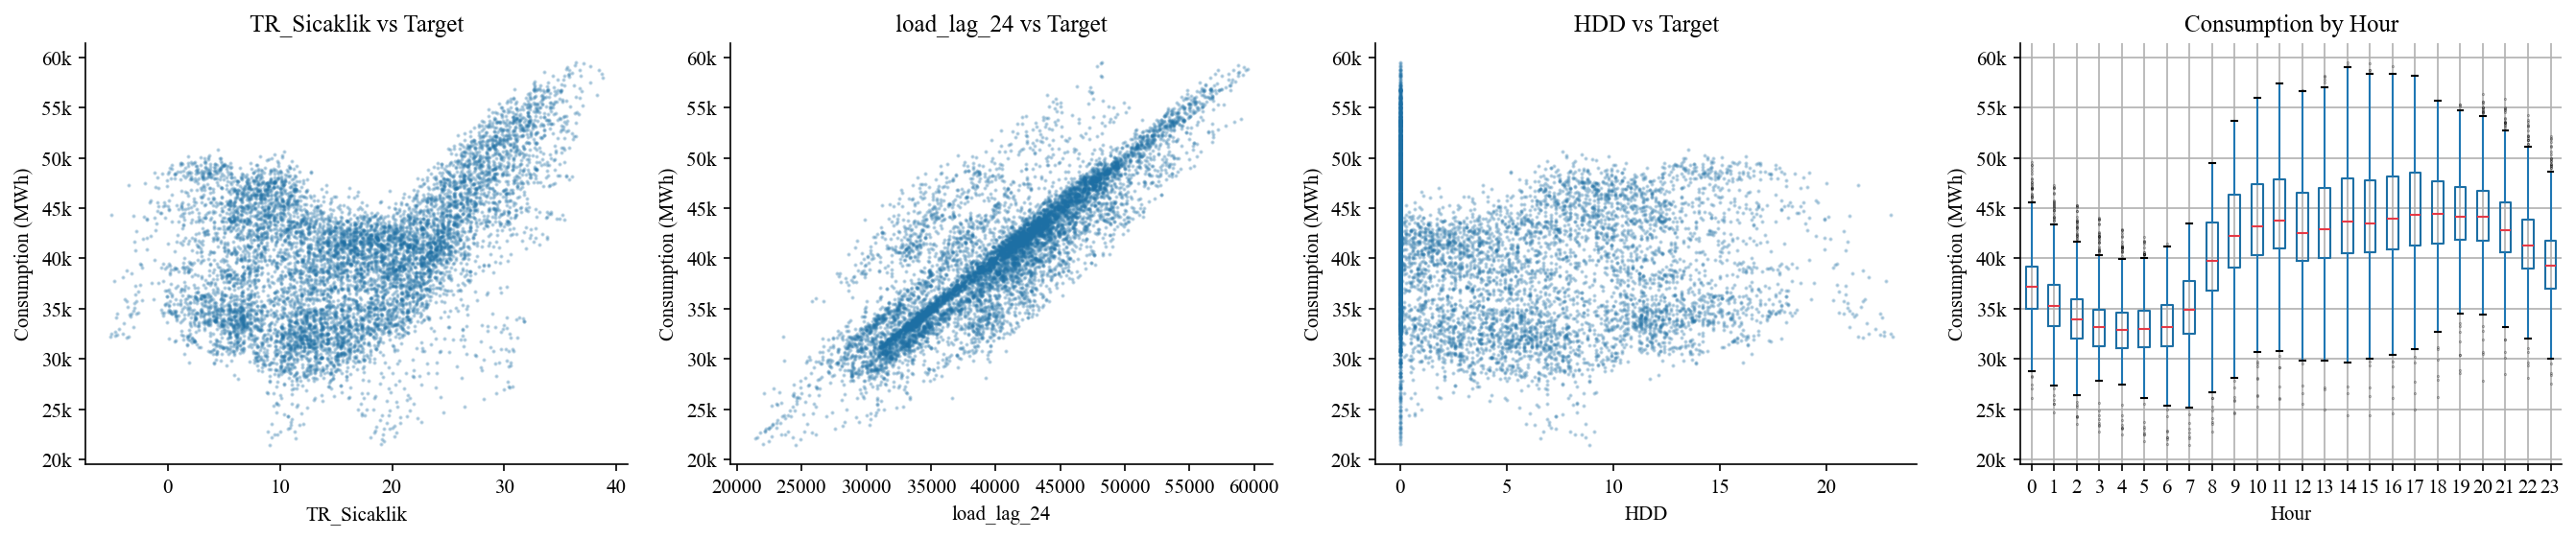

In [13]:
top_features = ['TR_Sicaklik', 'load_lag_24', 'HDD', 'hour']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, feat in enumerate(top_features[:3]):
    axes[i].scatter(df[feat], df[target], s=1, alpha=0.25, color='#1d6fa4')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Consumption (MWh)')
    axes[i].set_title(f'{feat} vs Target')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Box plot for hour
df.boxplot(column=target, by='hour', ax=axes[3], 
           flierprops=dict(marker='.', markersize=1, alpha=0.3),
           boxprops=dict(color='#1d6fa4'), medianprops=dict(color='#e63946'))
axes[3].set_title('Consumption by Hour')
axes[3].set_xlabel('Hour')
axes[3].set_ylabel('Consumption (MWh)')
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.suptitle('')

plt.tight_layout()
plt.show()

**Observations:**
- **Temperature vs consumption** shows a clear U-shape: consumption rises in both cold (heating) and hot (cooling) extremes. This validates the `HDD` and `temp_sq` engineered features.
- **load_lag_24** is highly correlated with the target (r ≈ 0.95), confirming strong daily autocorrelation.
- **Hour-of-day** box plot reveals a bimodal daily pattern: a morning ramp-up (07-12h) and an evening peak (17-21h), with nighttime troughs.
- **is_weekend** depresses consumption noticeably, consistent with reduced industrial/commercial demand.

### 6.3 Weekend effect & monthly patterns

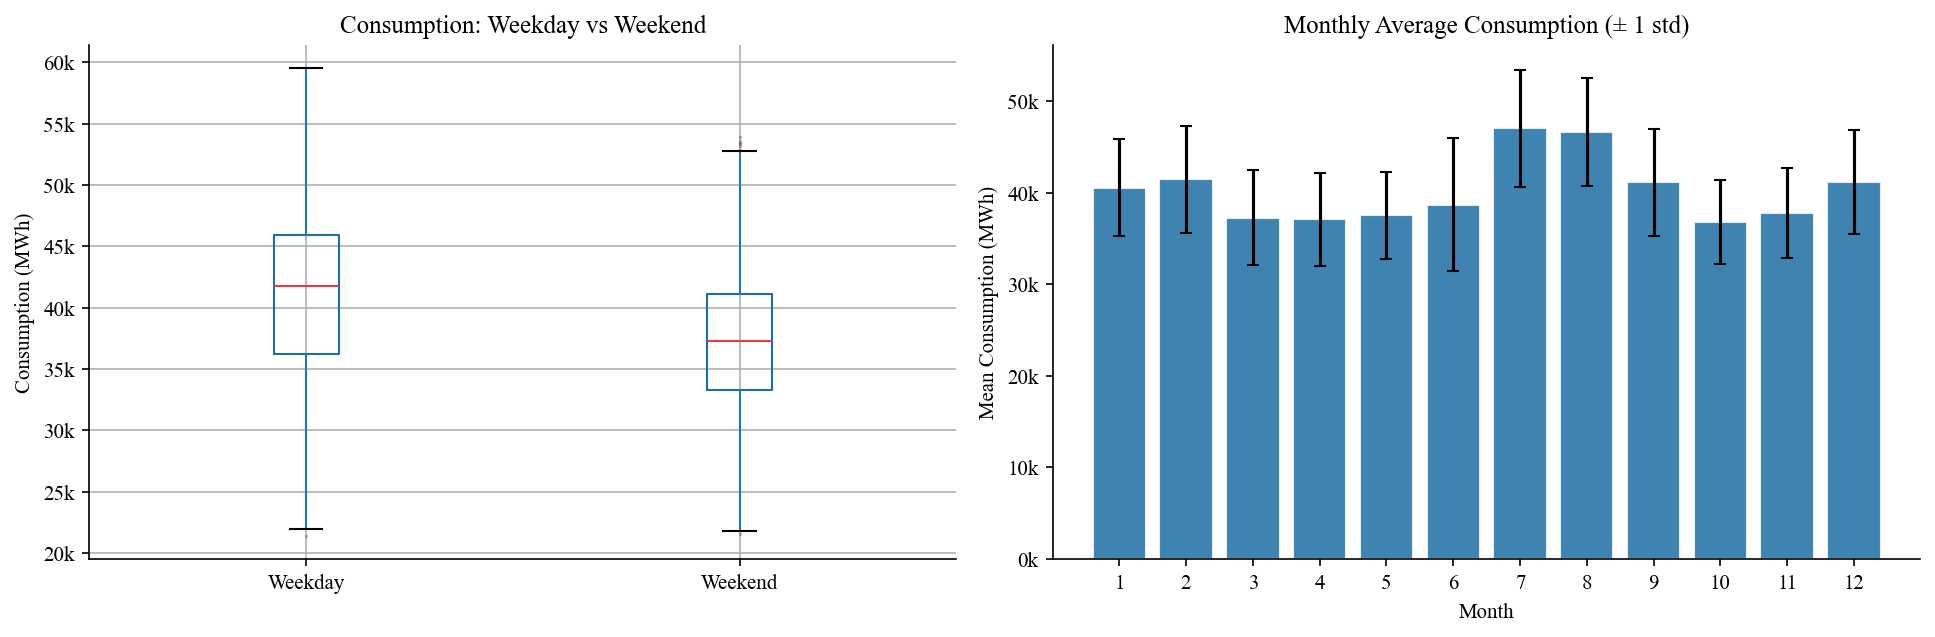

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Weekend effect
df.boxplot(column=target, by='is_weekend', ax=axes[0],
           boxprops=dict(color='#1d6fa4'), medianprops=dict(color='#e63946'),
           flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[0].set_xticklabels(['Weekday', 'Weekend'])
axes[0].set_title('Consumption: Weekday vs Weekend')
axes[0].set_xlabel('')
axes[0].set_ylabel('Consumption (MWh)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.suptitle('')

# Monthly
monthly = df.groupby('month')[target].agg(['mean','std'])
axes[1].bar(monthly.index, monthly['mean'], yerr=monthly['std'], capsize=3,
            color='#1d6fa4', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean Consumption (MWh)')
axes[1].set_title('Monthly Average Consumption (± 1 std)')
axes[1].set_xticks(range(1,13))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.show()

---
## 7. Key Findings & Next Steps

### Key Findings

1. **Strong autoregressive signal:** The 24-hour and 168-hour lag features are the single most predictive inputs (r > 0.90), indicating that recent consumption history is the dominant predictor.

2. **Non-linear temperature effect:** The relationship between temperature and consumption is U-shaped — both heating and cooling demand drive peaks. The engineered `HDD` and `temp_sq` features capture this well.

3. **Calendar effects are significant:** Weekends reduce mean consumption by ≈ 5 000 MWh. Holidays and Ramadan hours also show distinct patterns, justifying dedicated binary flags.

4. **Precipitation is sparse and highly skewed** (skewness ≈ 8.5). Most hours have zero rainfall; it may add limited predictive power on its own but could interact with temperature.

5. **No missing values or duplicates** — the dataset is clean and ready for modelling after dropping the redundant `Tarih`/`Saat` columns and the leaky `load_rolling_mean_24h`.

### Most Predictive Features

`load_lag_24`, `load_lag_168`, `HDD`, `TR_Sicaklik`, `temp_sq`, `hour`, `is_weekend`

### Remaining Data Quality Notes

- Weather features are country-wide averages; regional granularity could improve accuracy.
- The dataset covers a single calendar year (2025), so the model cannot learn inter-year trends.

### Next Steps (P2 & P3)

- **P2:** Train regression models (baseline linear → gradient boosting → LSTM / Dual-Attention network) using the features identified here.
- **P3:** Evaluate models with MAE, RMSE, R² on a held-out test set; add uncertainty quantification (MC Dropout) and interpret results.

https://github.com/arinakbas/Energy-Time-Series-Prediction